# 90 — EDA guiada: conhecendo a base de internações da Paraíba

**Para quem é este notebook:** para o Pedro. **O que ele é:** um roteiro de exploração,
não um relatório pronto. A ideia é você rodar célula por célula, ver o resultado com os
próprios olhos e sair daqui sabendo defender cada número da apresentação do dia 07/08.

> **"EDA" quer dizer *análise exploratória de dados*** — a etapa em que a gente faz
> perguntas simples aos dados ("quantas linhas tem?", "que período cobre?") antes de
> fazer as perguntas difíceis. É o equivalente a ler o rótulo antes de cozinhar.

## Como usar

1. Abra este arquivo no Jupyter (`jupyter notebook` no terminal, dentro da pasta do projeto).
2. Rode **na ordem, de cima para baixo**: clique numa célula cinza (as de código) e aperte
   **Shift + Enter**. O resultado aparece logo abaixo dela.
3. A ordem importa: as células de baixo usam coisas que as de cima criaram. Se algo der
   erro, quase sempre é porque uma célula anterior não foi rodada.
4. Onde aparecer **🔎 Sua vez**, tem uma linha para você trocar (o nome de uma cidade, um
   número) e rodar de novo. É ali que a exploração vira sua.

## O que este notebook responde, nesta ordem

| Seção | Pergunta |
|---|---|
| 1 | O que é uma linha desta base? Quantas são? Que período cobrem? |
| 2 | Quantas cidades aparecem — e por que "cidade onde mora" e "cidade onde internou" têm contagens tão diferentes? |
| 3 | Quantas pessoas se internam **fora** da cidade onde moram? |
| 4 | **Para onde** elas vão? |
| 5 | Quais cidades mais **perdem** moradores? |
| 6 | E no nível das **regiões de saúde**: quais dependem mais de fora? |
| 7 | Conferência: os números daqui batem com os que já estão nos relatórios do projeto? |

**Este notebook é autocontido:** ele não depende de nenhum outro notebook ter sido rodado
antes, e não acessa a internet. Tudo sai dos arquivos que já estão dentro do projeto.

## 0. Preparação

A célula abaixo faz três coisas de arrumação, nada de análise ainda:

- **importa as ferramentas** — `pandas` é a biblioteca que lê tabelas em Python (pense
  numa "planilha programável"); `matplotlib` é a que desenha gráficos;
- **garante que estamos na pasta certa** — se você abriu o notebook de dentro de
  `notebooks/`, o Python precisa "subir um andar" para achar as pastas `data/` e `outputs/`;
- **define dois formatadores** (`br_milhar`, `br_pct`) para os números saírem no padrão
  brasileiro: `258.125` e `50,5%`, e não `258125` e `50.5%`.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Se o notebook foi aberto de dentro de notebooks/, sobe um nível até a raiz do projeto.
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Pasta de trabalho:", Path.cwd())

# Paleta usada em todo o projeto (mesmas cores dos gráficos que já estão em outputs/figures).
COR_DESTAQUE, COR_NEUTRA, COR_AZUL = "#B03A2E", "#AAB7B8", "#1F618D"
plt.rcParams["figure.dpi"] = 110


def br_milhar(valor) -> str:
    '''12345 -> '12.345' (separador de milhar brasileiro).'''
    return f"{valor:,.0f}".replace(",", ".")


def br_pct(valor, casas: int = 1) -> str:
    '''50.53 -> '50,5%' (vírgula decimal brasileira).'''
    return f"{valor:.{casas}f}%".replace(".", ",")


print("Tudo pronto. Exemplo de formatação:", br_milhar(258125), "e", br_pct(50.53))

Pasta de trabalho: C:\Users\augus\workspace\faculdade\analise-de-dados\projetos\projeto-saude
Tudo pronto. Exemplo de formatação: 258.125 e 50,5%


## 1. O que é uma linha desta base?

A base do projeto é o **SIH** — o Sistema de Informações Hospitalares do SUS, publicado
pelo Ministério da Saúde (DATASUS). Todo mês, cada hospital público manda para o
Ministério a lista das internações que fez. É esse arquivo que a gente baixou, limpou e
guardou dentro do projeto.

**Cada linha é uma internação** (mais precisamente: uma AIH — Autorização de Internação
Hospitalar, o documento que autoriza e paga aquela internação). Isso tem uma consequência
que vale decorar, porque é a primeira coisa que um professor pergunta:

> ⚠️ **Uma linha não é uma pessoa.** Quem internou três vezes em 2025 aparece três vezes.
> Todos os números deste projeto medem **volume de internações**, não quantidade de
> indivíduos.

O arquivo que vamos abrir é o `sih_pb_2025_regioes.parquet`. O `.parquet` é só um formato
de arquivo de tabela — como um `.csv`, mas comprimido e muito mais rápido de ler. Ele é a
versão já tratada da base: nomes de cidade preenchidos e região de saúde atribuída.

In [2]:
base = pd.read_parquet("data/processed/sih_pb_2025_regioes.parquet")

print(f"Linhas (internações): {br_milhar(len(base))}")
print(f"Colunas (informações por internação): {base.shape[1]}")

Linhas (internações): 258.125
Colunas (informações por internação): 120


São **120 colunas** — quase tudo que o hospital informa: diagnóstico, idade, valor pago,
dias de permanência, se houve óbito... Mas **nem toda coluna é confiável ou útil**: boa
parte vem vazia ou com um valor fixo.

> 📁 Antes de usar qualquer coluna que não esteja neste roteiro, consulte
> **`docs/dados/dicionario-dados.md`**. Ele foi escrito exatamente para isso: diz o que cada
> coluna significa e dá um veredito de **"usável"** ou **"descartada, e por quê"**. Das 120,
> cerca de 46 são usáveis.

As quatro colunas que sustentam o projeto inteiro são estas:

| Coluna | O que é |
|---|---|
| `nome_mun_res` | cidade onde o paciente **mora** |
| `nome_mun_mov` | cidade onde ele **internou** |
| `regiao_res` | região de saúde onde ele mora (ou `Fora da PB`) |
| `regiao_int` | região de saúde do hospital |

Quando `nome_mun_res` é diferente de `nome_mun_mov`, aquele paciente **viajou para
internar**. É essa comparação, repetida 258 mil vezes, que dá origem a todo o projeto.

Vamos olhar cinco linhas de verdade:

In [3]:
COLUNAS_CHAVE = ["MES_CMPT", "nome_mun_res", "regiao_res", "nome_mun_mov", "regiao_int"]

# .sample(5) sorteia 5 linhas quaisquer; random_state=42 faz o sorteio ser sempre o mesmo,
# para você e eu vermos exatamente as mesmas linhas ao rodar.
base[COLUNAS_CHAVE].sample(5, random_state=42)

,MES_CMPT,nome_mun_res,regiao_res,nome_mun_mov,regiao_int
37970,2,João Pessoa,1ª Região Mata Atlântica - PB,João Pessoa,1ª Região Mata Atlântica - PB
203779,10,Patos,6ª Região - PB,Patos,6ª Região - PB
236607,11,João Pessoa,1ª Região Mata Atlântica - PB,João Pessoa,1ª Região Mata Atlântica - PB
206215,10,Santa Luzia,6ª Região - PB,Santa Rita,1ª Região Mata Atlântica - PB
75803,4,Campina Grande,16ª Região - PB,Campina Grande,16ª Região - PB


Leia a tabela acima linha por linha. Onde a 2ª e a 4ª coluna trazem cidades **diferentes**,
houve deslocamento. Onde a 3ª e a 5ª trazem regiões **diferentes**, o deslocamento foi
grande o bastante para atravessar a divisão administrativa do SUS — e é esse o caso que o
índice de dependência do projeto mede.

### 1.1 Que período estes dados cobrem?

A coluna `MES_CMPT` é o mês de **competência**: o mês a que a internação se refere na
contabilidade do SUS. Vamos conferir que temos os 12 meses de 2025 completos, sem buraco.

In [4]:
print("Anos presentes na base:", sorted(base["ANO_CMPT"].unique()))

por_mes = base.groupby("MES_CMPT").size()
print(f"Meses presentes: {len(por_mes)} (esperado: 12)")
print(f"Menor mês: {br_milhar(por_mes.min())} internações · "
      f"Maior mês: {br_milhar(por_mes.max())} internações")
print(f"Soma dos 12 meses: {br_milhar(por_mes.sum())} — tem de bater com o total da base.")

Anos presentes na base: [np.int64(2025)]
Meses presentes: 12 (esperado: 12)
Menor mês: 19.248 internações · Maior mês: 23.200 internações
Soma dos 12 meses: 258.125 — tem de bater com o total da base.


Essa última linha é uma **validação de soma**: se o total por mês não fechasse com o total
da base, teríamos perdido (ou duplicado) linhas em algum passo. Bateu.

Agora o primeiro gráfico. Repare no **título**: no projeto inteiro, o título de um gráfico
**afirma o achado** ("nenhum mês foge do padrão"), em vez de só rotular o eixo
("internações por mês"). É uma regra de comunicação: quem olha o slide por 3 segundos
precisa sair com a conclusão, não com a tarefa de descobri-la.

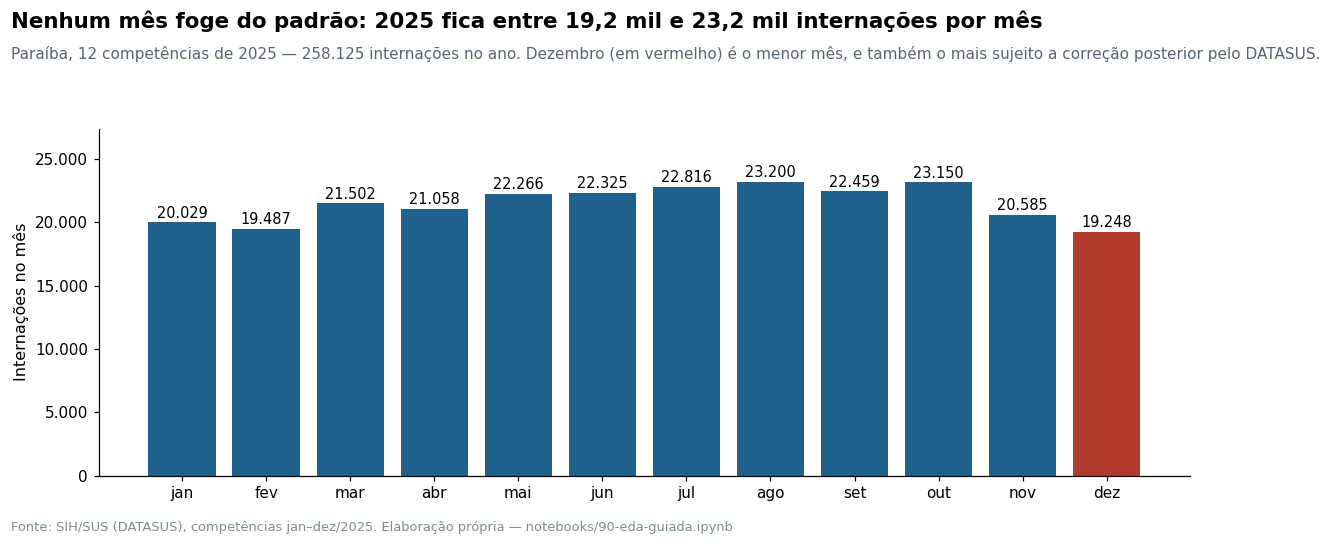

Figura salva em outputs/figures/eda_volume_mensal.png


In [5]:
MESES = ["jan", "fev", "mar", "abr", "mai", "jun",
         "jul", "ago", "set", "out", "nov", "dez"]

fig, ax = plt.subplots(figsize=(11, 4.8))
cores = [COR_DESTAQUE if m == 12 else COR_AZUL for m in por_mes.index]
barras = ax.bar(MESES, por_mes.values, color=cores)

for barra, valor in zip(barras, por_mes.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 350,
            br_milhar(valor), ha="center", fontsize=9.5)

ax.set_ylim(0, por_mes.max() * 1.18)
ax.set_ylabel("Internações no mês", fontsize=10.5)
ax.yaxis.set_major_formatter(lambda v, _: br_milhar(v))
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)

# O título afirma o achado — e os dois números vêm da própria conta, não digitados à mão.
menor_mil = f"{por_mes.min() / 1000:.1f}".replace(".", ",")
maior_mil = f"{por_mes.max() / 1000:.1f}".replace(".", ",")
fig.suptitle(f"Nenhum mês foge do padrão: 2025 fica entre {menor_mil} mil e {maior_mil} mil internações por mês",
             fontsize=14, fontweight="bold", x=0.012, ha="left", y=0.99)
fig.text(0.012, 0.90,
         f"Paraíba, 12 competências de 2025 — {br_milhar(len(base))} internações no ano. "
         "Dezembro (em vermelho) é o menor mês, e também o mais sujeito a correção posterior pelo DATASUS.",
         fontsize=10, color="#566573", ha="left")
fig.text(0.012, 0.005,
         "Fonte: SIH/SUS (DATASUS), competências jan–dez/2025. Elaboração própria — notebooks/90-eda-guiada.ipynb",
         fontsize=8.5, color="#7F8C8D", ha="left")

fig.tight_layout(rect=[0, 0.03, 1, 0.87])
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("outputs/figures/eda_volume_mensal.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Figura salva em outputs/figures/eda_volume_mensal.png")

**O que ler nesse gráfico:** a barra mais alta tem cerca de 20% a mais que a mais baixa —
ou seja, não existe um mês em que o sistema hospitalar da Paraíba "para" ou "explode". Isso
importa para a apresentação porque sustenta uma frase forte: **o que a gente vai mostrar
não é um pico de um mês, é o funcionamento normal do ano.**

⚠️ **A ressalva de dezembro**, que vale dizer antes que perguntem: dezembro é a competência
mais recente e é a que o DATASUS mais retifica depois. Ele é o menor mês do ano, mas com
esta base **não dá para separar** "teve menos internação mesmo" de "ainda não foi tudo
registrado". A gente declara isso e não extrapola.

## 2. Quantas cidades aparecem — e por que os dois lados não batem?

Agora uma pergunta que parece boba e revela o achado mais importante do projeto: quantas
cidades diferentes aparecem como **residência** e quantas aparecem como **local de
internação**?

`.nunique()` significa "número de valores distintos" — quantos nomes de cidade diferentes
existem naquela coluna.

In [6]:
cidades_residencia = base["nome_mun_res"].nunique()
cidades_internacao = base["nome_mun_mov"].nunique()

residentes_pb = base[base["regiao_res"] != "Fora da PB"]
cidades_residencia_pb = residentes_pb["nome_mun_res"].nunique()

print(f"Cidades que aparecem como RESIDÊNCIA do paciente: {cidades_residencia}")
print(f"   dessas, cidades da Paraíba:                    {cidades_residencia_pb} (a PB tem 223)")
print(f"Cidades que aparecem como LOCAL DA INTERNAÇÃO:    {cidades_internacao}")

Cidades que aparecem como RESIDÊNCIA do paciente: 555
   dessas, cidades da Paraíba:                    223 (a PB tem 223)
Cidades que aparecem como LOCAL DA INTERNAÇÃO:    62


**Pare um segundo neste resultado — ele é o projeto inteiro em duas linhas.**

- **555 cidades de residência.** É mais que as 223 da Paraíba porque gente de outros
  estados também se interna em hospitais paraibanos. **Todas as 223 cidades da PB aparecem**:
  não existe município paraibano sem nenhum morador internado no ano.
- **Só 62 cidades de internação.** De 223 municípios, **apenas 62 registraram alguma
  internação pelo SUS em 2025**. Os outros 161 não internaram ninguém — ou não têm hospital
  com leito SUS, ou têm estrutura que não realiza internação.

Ou seja: o paciente pode morar em qualquer um dos 223 lugares, mas só pode internar em 62.
**A viagem não é escolha do paciente — é consequência de onde o SUS colocou os leitos.**
Guarde essa frase; ela é a resposta pronta para "mas as pessoas não escolhem ir para a
capital?".

### 🔎 Sua vez — o retrato da sua cidade

A célula abaixo monta o retrato de uma cidade qualquer da Paraíba. Troque o nome na
primeira linha pelo da sua cidade (ou pela de alguém que você conheça) e rode de novo com
**Shift + Enter**. Escreva o nome **exatamente como aparece na base**, com acento e maiúsculas:
`"Campina Grande"`, `"Patos"`, `"Sousa"`, `"Guarabira"`, `"Bayeux"`, `"Cajazeiras"`...

In [7]:
MINHA_CIDADE = "Guarabira"   # <-- TROQUE AQUI e rode de novo (Shift + Enter)

moradores = base[base["nome_mun_res"] == MINHA_CIDADE]

if len(moradores) == 0:
    print(f"Nenhuma internação de morador de '{MINHA_CIDADE}'. "
          "Confira a grafia (acento, maiúsculas) — o nome tem de ser idêntico ao da base.")
else:
    fora = moradores[moradores["nome_mun_res"] != moradores["nome_mun_mov"]]
    print(f"=== {MINHA_CIDADE} ===")
    print(f"Internações de moradores em 2025 .......... {br_milhar(len(moradores))}")
    print(f"Dessas, feitas FORA da própria cidade ..... {br_milhar(len(fora))} "
          f"({br_pct(len(fora) / len(moradores) * 100)})")
    print(f"Região de saúde ........................... {moradores['regiao_res'].mode()[0]}")
    print("\nPara onde esses moradores foram (top 5):")
    for destino, qtd in fora["nome_mun_mov"].value_counts().head(5).items():
        print(f"   {destino:<22} {br_milhar(qtd):>7}  ({br_pct(qtd / len(fora) * 100)} das saídas)")

=== Guarabira ===
Internações de moradores em 2025 .......... 3.540
Dessas, feitas FORA da própria cidade ..... 1.677 (47,4%)
Região de saúde ........................... 2ª Região - PB

Para onde esses moradores foram (top 5):


   João Pessoa              1.338  (79,8% das saídas)
   Santa Rita                 171  (10,2% das saídas)
   Mamanguape                  97  (5,8% das saídas)
   Campina Grande              47  (2,8% das saídas)
   Solânea                     12  (0,7% das saídas)


Vale rodar essa célula umas cinco vezes, com cidades de tamanhos diferentes. O padrão que
você vai ver — cidade pequena com taxa perto de 100%, cidade grande com taxa de um dígito —
é exatamente a análise PA-3 do projeto, e você acabou de reproduzi-la à mão.

## 3. Quantas internações acontecem fora da cidade onde o paciente mora?

Este é **o número que motivou o projeto**. A conta é uma comparação simples, repetida em
todas as linhas: `nome_mun_res != nome_mun_mov` (o `!=` quer dizer "é diferente de").
O resultado é uma coluna de verdadeiro/falso; somar essa coluna conta quantos "verdadeiro".

Vamos calcular de **duas maneiras**, porque as duas aparecem nos relatórios do projeto e
confundir uma com a outra é um erro fácil de cometer no dia da apresentação:

- **(A) todas as internações feitas na Paraíba** — inclui gente de outros estados que veio
  se internar aqui;
- **(B) só quem mora na Paraíba** — o denominador correto quando a frase falar de
  "paraibanos".

In [8]:
# (A) todas as internações realizadas em hospitais da PB
fora_mun_todas = int((base["nome_mun_res"] != base["nome_mun_mov"]).sum())
pct_fora_todas = fora_mun_todas / len(base) * 100

# (B) apenas internações de quem mora na PB
fora_mun_res = int((residentes_pb["nome_mun_res"] != residentes_pb["nome_mun_mov"]).sum())
pct_fora_res = fora_mun_res / len(residentes_pb) * 100

print("(A) Todas as internações em hospitais da PB")
print(f"    total ................ {br_milhar(len(base))}")
print(f"    fora do município .... {br_milhar(fora_mun_todas)}  ({br_pct(pct_fora_todas)})")
print()
print("(B) Só internações de quem MORA na PB")
print(f"    total ................ {br_milhar(len(residentes_pb))}")
print(f"    fora do município .... {br_milhar(fora_mun_res)}  ({br_pct(pct_fora_res)})")
print()
print(f"Internações de gente de fora da PB: "
      f"{br_milhar(len(base) - len(residentes_pb))} — a diferença entre os dois totais.")

(A) Todas as internações em hospitais da PB
    total ................ 258.125
    fora do município .... 130.379  (50,5%)

(B) Só internações de quem MORA na PB
    total ................ 256.623
    fora do município .... 128.877  (50,2%)

Internações de gente de fora da PB: 1.502 — a diferença entre os dois totais.


**As duas medidas estão certas; elas respondem a perguntas diferentes.** A regra que o
projeto adotou (e que está escrita em `reports/sumario-evidencias.md`):

- fala em **"movimento hospitalar do estado"** → use os **50,5%**;
- fala em **"paraibanos"** → use os **50,2%**.

Na prática dá quase no mesmo, porque só 1.502 das 258 mil internações são de gente de
fora — mas saber explicar a diferença é o tipo de coisa que separa "decorou o número" de
"entendeu o número".

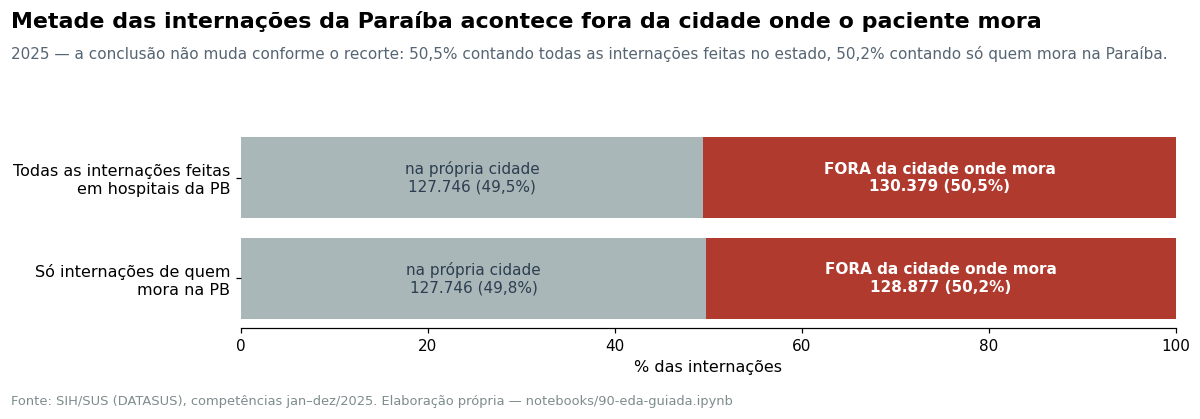

Figura salva em outputs/figures/eda_dentro_fora_municipio.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 3.6))

grupos = [
    ("Todas as internações feitas\nem hospitais da PB", len(base), fora_mun_todas),
    ("Só internações de quem\nmora na PB", len(residentes_pb), fora_mun_res),
]

for i, (rotulo, total, fora) in enumerate(grupos):
    dentro = total - fora
    ax.barh(i, dentro / total * 100, color=COR_NEUTRA)
    ax.barh(i, fora / total * 100, left=dentro / total * 100, color=COR_DESTAQUE)
    ax.text(dentro / total * 50, i, f"na própria cidade\n{br_milhar(dentro)} ({br_pct(dentro / total * 100)})",
            ha="center", va="center", fontsize=10, color="#2C3E50")
    ax.text(dentro / total * 100 + fora / total * 50, i,
            f"FORA da cidade onde mora\n{br_milhar(fora)} ({br_pct(fora / total * 100)})",
            ha="center", va="center", fontsize=10, color="white", fontweight="bold")

ax.set_yticks(range(len(grupos)))
ax.set_yticklabels([g[0] for g in grupos], fontsize=10.5)
ax.set_xlim(0, 100)
ax.set_xlabel("% das internações", fontsize=10.5)
ax.invert_yaxis()
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)

fig.suptitle("Metade das internações da Paraíba acontece fora da cidade onde o paciente mora",
             fontsize=14.5, fontweight="bold", x=0.012, ha="left", y=1.0)
fig.text(0.012, 0.88,
         "2025 — a conclusão não muda conforme o recorte: 50,5% contando todas as internações "
         "feitas no estado, 50,2% contando só quem mora na Paraíba.",
         fontsize=10, color="#566573", ha="left")
fig.text(0.012, 0.005,
         "Fonte: SIH/SUS (DATASUS), competências jan–dez/2025. Elaboração própria — notebooks/90-eda-guiada.ipynb",
         fontsize=8.5, color="#7F8C8D", ha="left")

fig.tight_layout(rect=[0, 0.04, 1, 0.84])
fig.savefig("outputs/figures/eda_dentro_fora_municipio.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Figura salva em outputs/figures/eda_dentro_fora_municipio.png")

**Um detalhe do gráfico que parece erro e não é.** As duas barras cinzas mostram o mesmo
número: **127.746**. Não é bug — é consequência lógica. Quem mora fora da Paraíba e se
interna aqui está, por definição, fora da própria cidade: não existe nenhuma chance de ele
cair no lado cinza. Então as 1.502 internações de não-residentes entram inteiras no lado
vermelho, e o lado cinza é idêntico nos dois recortes. A diferença entre 130.379 e 128.877
é exatamente 1.502. Confira você mesmo na conta acima — é o tipo de coerência interna que
dá confiança na base.

> 📌 **Sobre o 47,8% que você talvez tenha ouvido no começo do projeto.** Na fase de
> pesquisa, a dupla citava 47,8% para janeiro/2025. Ao refazer a conta com a base
> congelada, por cinco caminhos independentes, o resultado deu **49,8%, sempre**. O 47,8%
> não tinha memória de cálculo — não dava para provar de onde vinha. O projeto adotou o
> número que consegue provar. Vamos refazer essa conta agora, em uma linha:

In [10]:
janeiro = base[base["MES_CMPT"] == 1]
jan_fora = int((janeiro["nome_mun_res"] != janeiro["nome_mun_mov"]).sum())

print(f"Janeiro/2025: {br_milhar(len(janeiro))} internações, "
      f"{br_milhar(jan_fora)} fora do município "
      f"({br_pct(jan_fora / len(janeiro) * 100)})")

Janeiro/2025: 20.029 internações, 9.981 fora do município (49,8%)


## 4. Para onde vão os que saem da própria cidade?

Já sabemos que metade viaja. A pergunta seguinte é *para onde* — e a resposta é a diferença
entre dois diagnósticos opostos:

- se o destino fosse **espalhado**, a rede seria uma **malha**: cada cidade se apoiando nas
  vizinhas. Problema pequeno, solução de ajuste fino;
- se o destino for **concentrado**, a rede é um **funil**: quase todo mundo desaguando nos
  mesmos poucos endereços. Problema estrutural, exige redistribuir leitos.

Vamos contar os destinos de quem se internou fora de casa.

In [11]:
saiu_de_casa = base[base["nome_mun_res"] != base["nome_mun_mov"]]

ranking_destinos = (saiu_de_casa["nome_mun_mov"].value_counts()
                    .rename_axis("cidade_destino").reset_index(name="internacoes"))
ranking_destinos["pct"] = ranking_destinos["internacoes"] / len(saiu_de_casa) * 100
ranking_destinos["pct_acumulado"] = ranking_destinos["pct"].cumsum()

print(f"Cidades que recebem ao menos um paciente de fora: {len(ranking_destinos)}")
print(f"(das 62 que registram internação — as outras {62 - len(ranking_destinos)} só atendem o próprio morador)\n")
ranking_destinos.head(10).round(1)

Cidades que recebem ao menos um paciente de fora: 55
(das 62 que registram internação — as outras 7 só atendem o próprio morador)



,cidade_destino,internacoes,pct,pct_acumulado
0,João Pessoa,43624,33.5,33.5
1,Campina Grande,32817,25.2,58.6
2,Patos,11147,8.5,67.2
3,Santa Rita,6507,5.0,72.2
4,Cajazeiras,4573,3.5,75.7
5,Mamanguape,4308,3.3,79.0
6,Guarabira,4267,3.3,82.3
7,Sousa,2862,2.2,84.4
8,Pombal,2504,1.9,86.4
9,Catolé do Rocha,2444,1.9,88.2


In [12]:
pct_dois_polos = ranking_destinos["pct_acumulado"].iloc[1]
pct_tres_polos = ranking_destinos["pct_acumulado"].iloc[2]

print(f"João Pessoa + Campina Grande ........ {br_pct(pct_dois_polos)} de tudo que se desloca")
print(f"Somando Patos (3 polos) ............. {br_pct(pct_tres_polos)}")

João Pessoa + Campina Grande ........ 58,6% de tudo que se desloca
Somando Patos (3 polos) ............. 67,2%


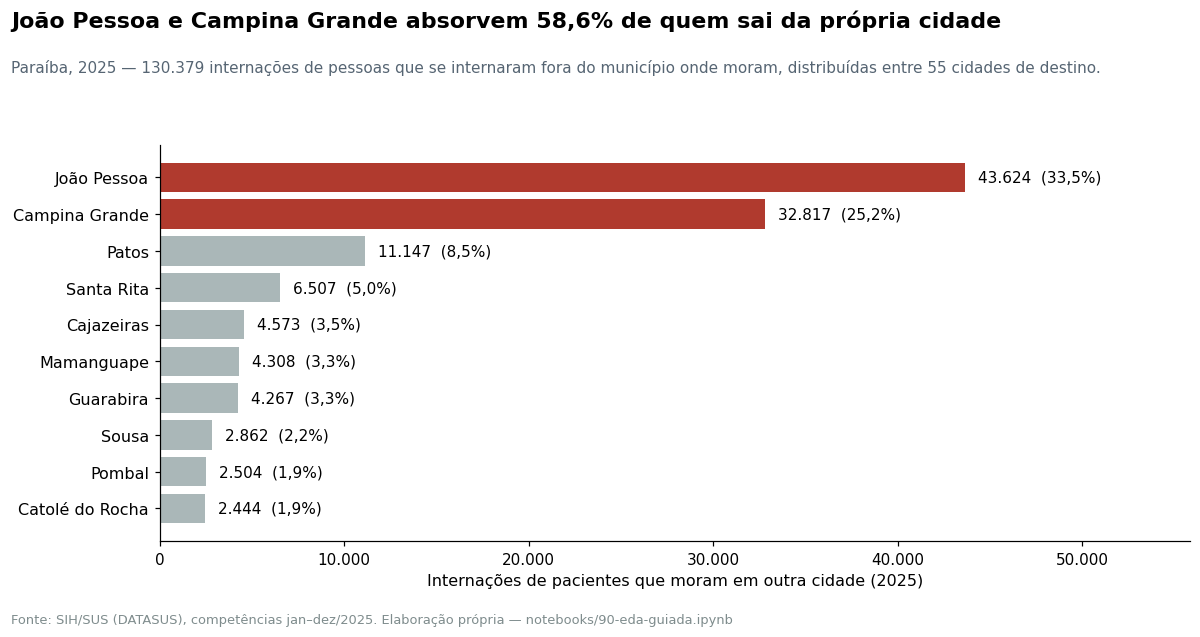

Figura salva em outputs/figures/eda_top_destinos.png


In [13]:
top10 = ranking_destinos.head(10).iloc[::-1]   # invertido: maior fica no topo do gráfico
cores = [COR_DESTAQUE if c in ("João Pessoa", "Campina Grande") else COR_NEUTRA
         for c in top10["cidade_destino"]]

fig, ax = plt.subplots(figsize=(11, 5.6))
barras = ax.barh(top10["cidade_destino"], top10["internacoes"], color=cores)
for barra, (_, linha) in zip(barras, top10.iterrows()):
    ax.text(barra.get_width() + 700, barra.get_y() + barra.get_height() / 2,
            f"{br_milhar(linha['internacoes'])}  ({br_pct(linha['pct'])})",
            va="center", fontsize=10)

ax.set_xlim(0, ranking_destinos["internacoes"].max() * 1.28)
ax.set_xlabel("Internações de pacientes que moram em outra cidade (2025)", fontsize=10.5)
ax.xaxis.set_major_formatter(lambda v, _: br_milhar(v))
ax.tick_params(axis="y", labelsize=10.5)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)

fig.suptitle(f"João Pessoa e Campina Grande absorvem {br_pct(pct_dois_polos)} de quem sai da própria cidade",
             fontsize=14.5, fontweight="bold", x=0.012, ha="left", y=1.0)
fig.text(0.012, 0.90,
         f"Paraíba, 2025 — {br_milhar(len(saiu_de_casa))} internações de pessoas que se internaram "
         "fora do município onde moram, distribuídas entre 55 cidades de destino.",
         fontsize=10, color="#566573", ha="left")
fig.text(0.012, 0.005,
         "Fonte: SIH/SUS (DATASUS), competências jan–dez/2025. Elaboração própria — notebooks/90-eda-guiada.ipynb",
         fontsize=8.5, color="#7F8C8D", ha="left")

fig.tight_layout(rect=[0, 0.035, 1, 0.87])
fig.savefig("outputs/figures/eda_top_destinos.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Figura salva em outputs/figures/eda_top_destinos.png")

**Veredito:** é funil, não malha. Duas cidades, de 223, recebem 6 de cada 10 pacientes que
precisam sair de casa. É esse número — **58,6%** — que sustenta a primeira recomendação da
narrativa executiva (financiar formalmente os polos na pactuação estadual, já que eles de
fato já operam como polos, com ou sem contrato).

## 5. Quais cidades mais perdem moradores?

Aqui tem uma armadilha de leitura que vale entender bem, porque ela muda a resposta:
**"perder mais" pode significar duas coisas diferentes.**

- **Volume** — quantos moradores, em número absoluto, se internam fora. Cidade grande tende
  a liderar só por ser grande.
- **Taxa** — que *percentual* dos moradores se interna fora. Aqui cidade pequena lidera,
  porque muitas simplesmente não têm hospital.

Vamos ver as duas, lado a lado, só para quem mora na Paraíba.

In [14]:
por_cidade = residentes_pb.assign(
    saiu=residentes_pb["nome_mun_res"] != residentes_pb["nome_mun_mov"]
).groupby("nome_mun_res").agg(
    internacoes_de_moradores=("saiu", "size"),
    internacoes_fora=("saiu", "sum"),
)
por_cidade["taxa_pct"] = (por_cidade["internacoes_fora"] / por_cidade["internacoes_de_moradores"] * 100).round(1)

print("TOP 8 por VOLUME (quantos moradores saem):")
print(por_cidade.sort_values("internacoes_fora", ascending=False).head(8).to_string())

print("\nPor TAXA, o ranking não funciona — há empate no teto:")
no_teto = por_cidade[por_cidade["taxa_pct"] == 100]
print(f"   {len(no_teto)} das {len(por_cidade)} cidades da PB têm taxa de EXATAMENTE 100%")
print("   (nenhum morador delas se internou dentro da própria cidade, o ano inteiro).")
print(f"   Somadas, são {br_milhar(no_teto['internacoes_fora'].sum())} internações.")
print("\n   As 5 maiores entre elas, por volume:")
print(no_teto.sort_values("internacoes_fora", ascending=False).head(5).to_string())

TOP 8 por VOLUME (quantos moradores saem):
              internacoes_de_moradores  internacoes_fora  taxa_pct
nome_mun_res                                                      
Santa Rita                        9997              5788      57.9
Bayeux                            4733              4718      99.7
Sapé                              2960              2372      80.1
Cabedelo                          4031              2317      57.5
João Pessoa                      51512              1863       3.6
Conde                             1833              1833     100.0
Queimadas                         2820              1794      63.6
Guarabira                         3540              1677      47.4

Por TAXA, o ranking não funciona — há empate no teto:
   161 das 223 cidades da PB têm taxa de EXATAMENTE 100%
   (nenhum morador delas se internou dentro da própria cidade, o ano inteiro).
   Somadas, são 64.040 internações.

   As 5 maiores entre elas, por volume:
              inter

**Repare no que aconteceu com o ranking por taxa: ele não existe.** São **161 cidades
empatadas em 100%**. E esse 161 não é coincidência: é exatamente **223 − 62**, as cidades
da Paraíba menos as que registram alguma internação. Ou seja, toda cidade sem leito SUS
tem taxa de 100% **por definição** — não há outro resultado possível para ela. O ranking
por taxa está medindo, na verdade, "a cidade tem hospital ou não".

Isso fecha o raciocínio da seção 2 por outro caminho, e é uma boa checagem de coerência da
base: dois cálculos independentes (contar cidades de destino e contar cidades com taxa de
100%) chegam ao mesmo 62/161. Por isso o projeto usa **faixa de porte**
(a análise PA-3, em `outputs/tables/pa3_evasao_por_porte.csv`) em vez de ranking de cidade:
a taxa média cai de 98,1% nas cidades de até 10 mil habitantes para 9,3% nas acima de 100
mil, sem uma única inversão pelo caminho.

⚠️ **Duas leituras erradas que este resultado convida — e que precisam ser desarmadas na
apresentação:**

1. **"Bayeux e Santa Rita são as mais abandonadas do estado."** Não. Elas são **coladas em
   João Pessoa** — o morador de Bayeux atravessa uma avenida para chegar ao hospital.
   Trocar de município **não é o mesmo que percorrer distância**, e esta base não mede
   quilômetro nenhum. A taxa de 99,7% de Bayeux é real, mas o sofrimento que ela sugere,
   não necessariamente.
2. **"João Pessoa tem taxa baixa porque é rica."** A taxa de João Pessoa é baixa porque os
   leitos estão lá. A causa é a mesma que explica a taxa alta das outras: **onde tem
   hospital, não se viaja.**

O antídoto para as duas é a mesma medida: parar de olhar município e passar a olhar
**região de saúde** — que é justamente a próxima seção.

### 🔎 Sua vez — compare duas cidades

Troque os dois nomes abaixo e rode. Sugestões que rendem boa conversa:
`("Bayeux", "Cajazeiras")` — vizinha de capital contra cidade isolada do sertão;
`("Patos", "Sousa")` — dois polos do sertão de portes diferentes.

In [15]:
CIDADE_A, CIDADE_B = "Bayeux", "Cajazeiras"   # <-- TROQUE AQUI e rode de novo

for cidade in (CIDADE_A, CIDADE_B):
    if cidade not in por_cidade.index:
        print(f"'{cidade}' não encontrada — confira a grafia.\n")
        continue
    linha = por_cidade.loc[cidade]
    print(f"{cidade}: {br_milhar(linha['internacoes_de_moradores'])} internações de moradores, "
          f"{br_milhar(linha['internacoes_fora'])} fora ({br_pct(linha['taxa_pct'])})")

Bayeux: 4.733 internações de moradores, 4.718 fora (99,7%)
Cajazeiras: 5.080 internações de moradores, 847 fora (16,7%)


## 6. Subindo o nível: as regiões de saúde

O SUS não planeja município por município — planeja por **região de saúde**: grupos de
municípios vizinhos que, pelo desenho oficial, deveriam **resolver juntos** a maior parte da
demanda. A Paraíba tem **16 regiões**. Cada internação da base já vem com a região do
paciente (`regiao_res`) e a do hospital (`regiao_int`).

Isso resolve a armadilha da seção anterior: se o morador de Bayeux se interna em João
Pessoa, ele trocou de município mas **não** de região — pela régua do SUS, a rede dele
funcionou. Só conta como problema quando a pessoa precisa **sair da própria região**.

E é exatamente essa a definição do número-assinatura do projeto:

> **Índice de dependência de uma região** = a porcentagem das internações de moradores
> daquela região que aconteceram **fora** dela.
>
> Índice de 84% quer dizer: de cada 100 internações de moradores dessa região, 84
> aconteceram em hospital de outra região. Quanto maior, mais a região depende de fora.

In [16]:
fora_da_regiao = int((residentes_pb["regiao_res"] != residentes_pb["regiao_int"]).sum())

print(f"Internações de residentes da PB ........... {br_milhar(len(residentes_pb))}")
print(f"Feitas FORA da região de saúde de moradia . {br_milhar(fora_da_regiao)} "
      f"({br_pct(fora_da_regiao / len(residentes_pb) * 100)})")

Internações de residentes da PB ........... 256.623
Feitas FORA da região de saúde de moradia . 67.633 (26,4%)


**Compare com a seção 3:** 50,2% saem do **município**, mas só 26,4% saem da **região**.
A diferença — cerca de metade — é deslocamento *dentro* da própria região, que é a rede
funcionando como foi desenhada. Os 26,4% são o problema de verdade.

⚠️ **Cuidado com o rótulo desse 26,4%:** ele é a **taxa do estado inteiro** (todas as
internações que saíram da região, sobre o total de internações de residentes). Ele **não é
a média dos 16 índices** — essa daria outro valor, porque região grande e região pequena
pesariam igual. Chame sempre de "taxa estadual", nunca de "média".

Agora o índice região por região:

In [17]:
indice = (residentes_pb.assign(
              saiu_da_regiao=residentes_pb["regiao_res"] != residentes_pb["regiao_int"])
          .groupby("regiao_res")
          .agg(internacoes_residentes=("saiu_da_regiao", "size"),
               internacoes_fora=("saiu_da_regiao", "sum")))
indice["indice_pct"] = (indice["internacoes_fora"] / indice["internacoes_residentes"] * 100).round(1)
indice = indice.sort_values("indice_pct", ascending=False)

regioes_criticas = int((indice["indice_pct"] > 50).sum())
print(f"Regiões com índice acima de 50%: {regioes_criticas} de {len(indice)}\n")
indice

Regiões com índice acima de 50%: 8 de 16



,internacoes_residentes,internacoes_fora,indice_pct
regiao_res,,,
3ª Região - PB,10815,9143,84.5
12ª Região - PB,10420,7479,71.8
15ª Região - PB,9540,6826,71.6
7ª Região - PB,8919,5029,56.4
11ª Região - PB,4280,2329,54.4
2ª Região - PB,16531,8986,54.4
4ª Região - PB,7075,3837,54.2
14ª Região - PB,10095,5249,52.0
5ª Região - PB,8458,3592,42.5


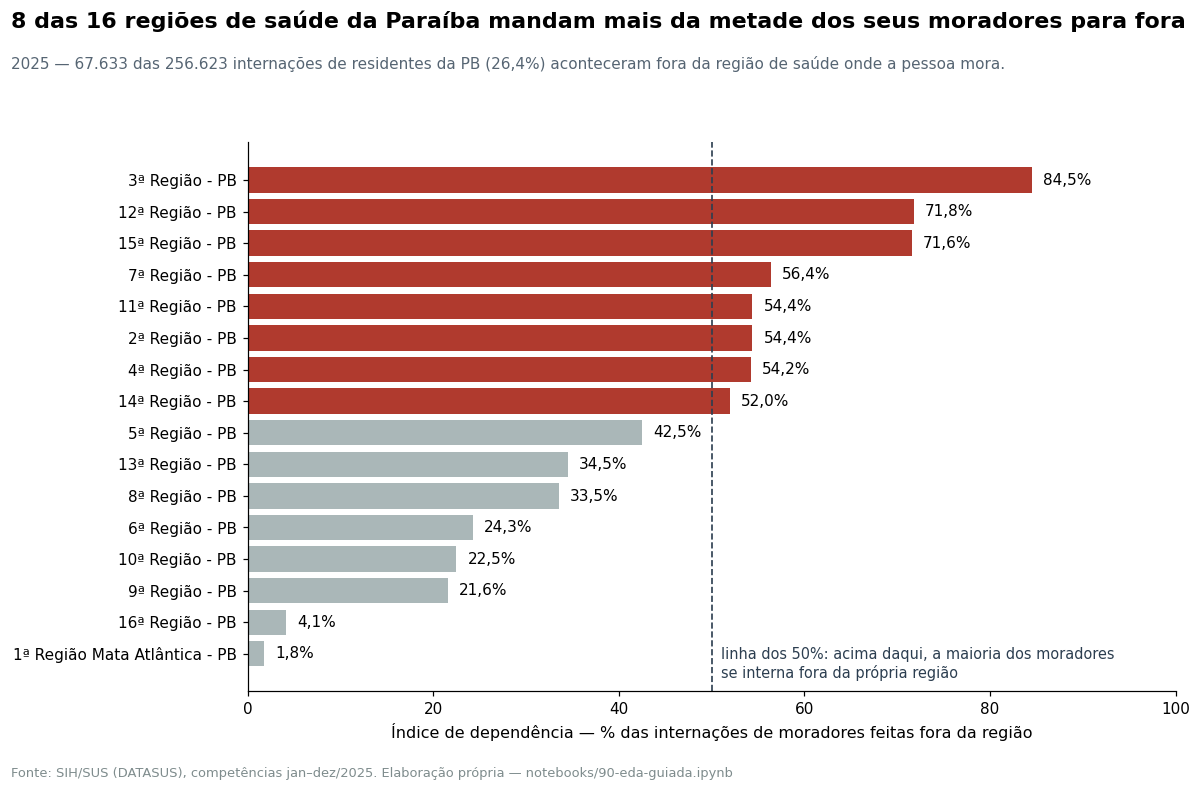

Figura salva em outputs/figures/eda_dependencia_regioes.png


In [18]:
ordenado = indice.iloc[::-1]   # menor índice embaixo... invertido para o maior ficar no topo
cores = [COR_DESTAQUE if v > 50 else COR_NEUTRA for v in ordenado["indice_pct"]]

fig, ax = plt.subplots(figsize=(11, 7))
barras = ax.barh(ordenado.index, ordenado["indice_pct"], color=cores)
for barra, valor in zip(barras, ordenado["indice_pct"]):
    ax.text(barra.get_width() + 1.2, barra.get_y() + barra.get_height() / 2,
            br_pct(valor), va="center", fontsize=10)

ax.axvline(50, color="#2C3E50", linewidth=1.1, linestyle="--")
ax.text(51, -0.75, "linha dos 50%: acima daqui, a maioria dos moradores\nse interna fora da própria região",
        fontsize=9.5, color="#2C3E50")
ax.set_xlim(0, 100)
ax.set_xlabel("Índice de dependência — % das internações de moradores feitas fora da região", fontsize=10.5)
ax.tick_params(axis="y", labelsize=10)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)

fig.suptitle(f"{regioes_criticas} das 16 regiões de saúde da Paraíba mandam mais da metade dos seus moradores para fora",
             fontsize=14.5, fontweight="bold", x=0.012, ha="left", y=1.0)
fig.text(0.012, 0.925,
         f"2025 — {br_milhar(fora_da_regiao)} das {br_milhar(len(residentes_pb))} internações de residentes da PB "
         f"({br_pct(fora_da_regiao / len(residentes_pb) * 100)}) aconteceram fora da região de saúde onde a pessoa mora.",
         fontsize=10, color="#566573", ha="left")
fig.text(0.012, 0.005,
         "Fonte: SIH/SUS (DATASUS), competências jan–dez/2025. Elaboração própria — notebooks/90-eda-guiada.ipynb",
         fontsize=8.5, color="#7F8C8D", ha="left")

fig.tight_layout(rect=[0, 0.03, 1, 0.90])
fig.savefig("outputs/figures/eda_dependencia_regioes.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Figura salva em outputs/figures/eda_dependencia_regioes.png")

**Como ler o gráfico, de cima para baixo:**

- No topo, a **3ª Região** (Monteiro, no Cariri): 84,5% — de cada 6 internações de
  moradores, 5 acontecem fora. É a região mais dependente do estado.
- No meio, a linha tracejada dos 50%. **8 regiões estão acima dela** — metade do estado.
- Na base, a **1ª Região Mata Atlântica** (João Pessoa) com 1,8% e a **16ª** (Campina
  Grande) com 4,1%. Não é mérito de gestão: é onde estão os hospitais que atendem as outras.

**A frase que resume:** as duas regiões dos polos praticamente não dependem de ninguém, e
metade do estado depende delas.

### 🔎 Sua vez — para onde vai cada região

Escolha uma região do gráfico e veja para onde os moradores dela vão quando saem.

In [19]:
MINHA_REGIAO = "3ª Região - PB"   # <-- TROQUE AQUI (copie o nome exato do gráfico acima)

moradores_reg = residentes_pb[residentes_pb["regiao_res"] == MINHA_REGIAO]

if len(moradores_reg) == 0:
    print(f"Região '{MINHA_REGIAO}' não encontrada. Copie o nome exato do eixo do gráfico.")
else:
    saidas = moradores_reg[moradores_reg["regiao_res"] != moradores_reg["regiao_int"]]
    print(f"=== {MINHA_REGIAO} ===")
    print(f"Internações de moradores ....... {br_milhar(len(moradores_reg))}")
    print(f"Saíram da região ............... {br_milhar(len(saidas))} "
          f"({br_pct(len(saidas) / len(moradores_reg) * 100)})\n")
    print("Para onde foram:")
    for destino, qtd in saidas["regiao_int"].value_counts().head(5).items():
        print(f"   {destino:<32} {br_milhar(qtd):>6}  ({br_pct(qtd / len(saidas) * 100)} das saídas)")

=== 3ª Região - PB ===
Internações de moradores ....... 10.815
Saíram da região ............... 9.143 (84,5%)

Para onde foram:
   16ª Região - PB                   7.639  (83,6% das saídas)
   1ª Região Mata Atlântica - PB       693  (7,6% das saídas)
   15ª Região - PB                     331  (3,6% das saídas)
   2ª Região - PB                      189  (2,1% das saídas)
   4ª Região - PB                      144  (1,6% das saídas)


Rode isso para as 8 regiões acima da linha e você vai notar o padrão que sustenta a segunda
recomendação do projeto: em **7 das 8**, a maioria das saídas vai para **um único destino**.
A dependência não é difusa ("um pouco para cada vizinho") — é dependência de um endereço só.
Isso muda o instrumento de gestão: pactuar com um parceiro é um problema bem diferente de
pactuar com sete.

## 7. Conferência: estes números batem com os do projeto?

Esta seção é a mais importante do notebook, e vale explicar por quê.

Este notebook recalculou tudo **do zero**, direto da base bruta tratada. Os relatórios do
projeto (`reports/sumario-evidencias.md`, `reports/narrativa-executiva.md`) e as tabelas
prontas (`data/processed/`, `outputs/tables/`) foram produzidos por **outro caminho**:
os notebooks técnicos `01-*`, que passam por matrizes intermediárias.

Se os dois caminhos chegam ao mesmo número, o número é confiável. Se divergem, um dos dois
está errado — e é muito melhor descobrir isso agora do que no dia 07/08, com o professor
perguntando.

A célula abaixo compara, um a um, os números deste notebook com os publicados. Cada linha
mostra a origem do valor publicado, para você poder ir conferir na mão se quiser.

In [20]:
conferencias = []


def conferir(codigo, descricao, calculado, publicado, fonte, tolerancia=0.05):
    '''Compara um número calculado aqui com o valor publicado nos relatórios do projeto.'''
    bate = abs(float(calculado) - float(publicado)) <= tolerancia
    conferencias.append({
        "cód.": codigo,
        "número": descricao,
        "aqui": calculado,
        "publicado": publicado,
        "situação": "OK" if bate else "DIVERGE",
        "fonte do publicado": fonte,
    })


SUMARIO = "reports/sumario-evidencias.md"

# --- Seção 1 do sumário: o tamanho do problema
conferir("E-01", "Internações em hospitais da PB", len(base), 258125, SUMARIO, 0)
conferir("E-02", "Internações de residentes da PB", len(residentes_pb), 256623, SUMARIO, 0)
conferir("E-03", "Fora do município (todas)", fora_mun_todas, 130379, SUMARIO, 0)
conferir("E-03", "Fora do município (todas), %", round(pct_fora_todas, 1), 50.5, SUMARIO)
conferir("E-04", "Fora do município (só residentes)", fora_mun_res, 128877, SUMARIO, 0)
conferir("E-04", "Fora do município (só residentes), %", round(pct_fora_res, 1), 50.2, SUMARIO)
conferir("E-05", "Fora da região de saúde", fora_da_regiao, 67633, SUMARIO, 0)
conferir("E-05", "Fora da região de saúde, %", round(fora_da_regiao / len(residentes_pb) * 100, 1), 26.4, SUMARIO)
conferir("E-06", "Municípios da PB com internação registrada", cidades_internacao, 62, SUMARIO, 0)

# Coerência interna: as cidades com taxa de 100% têm de ser exatamente as 223 da PB
# menos as 62 que registram internação. Dois cálculos independentes, mesmo resultado.
conferir("—", "Cidades da PB com taxa de 100%", len(no_teto), 223 - cidades_internacao,
         "coerência interna (223 − 62)", 0)

# --- PA-1: concentração de destino
conferir("P1-01", "João Pessoa recebe", int(ranking_destinos.loc[0, "internacoes"]), 43624, SUMARIO, 0)
conferir("P1-01", "João Pessoa, % do fluxo", round(ranking_destinos.loc[0, "pct"], 1), 33.5, SUMARIO)
conferir("P1-02", "Campina Grande recebe", int(ranking_destinos.loc[1, "internacoes"]), 32817, SUMARIO, 0)
conferir("P1-02", "Campina Grande, % do fluxo", round(ranking_destinos.loc[1, "pct"], 1), 25.2, SUMARIO)
conferir("P1-03", "Os dois polos juntos, %", round(pct_dois_polos, 1), 58.6, SUMARIO)
conferir("P1-04", "Com Patos (três polos), %", round(pct_tres_polos, 1), 67.2, SUMARIO)
conferir("P1-07", "Municípios que recebem alguém de fora", len(ranking_destinos), 55, SUMARIO, 0)

# --- PA-2: índice de dependência
conferir("P2-01", "Regiões com índice > 50%", regioes_criticas, 8, SUMARIO, 0)
conferir("P2-02", "3ª Região (a mais dependente), %", indice.loc["3ª Região - PB", "indice_pct"], 84.5, SUMARIO)
conferir("P2-03", "1ª Mata Atlântica (a menos dependente), %",
         indice.loc["1ª Região Mata Atlântica - PB", "indice_pct"], 1.8, SUMARIO)
conferir("P2-03", "16ª Região (Campina Grande), %", indice.loc["16ª Região - PB", "indice_pct"], 4.1, SUMARIO)

# --- PA-3: taxa dos próprios polos
conferir("P3-04", "João Pessoa: taxa dos próprios moradores, %",
         por_cidade.loc["João Pessoa", "taxa_pct"], 3.6, SUMARIO)
conferir("P3-05", "Campina Grande: idem, %",
         por_cidade.loc["Campina Grande", "taxa_pct"], 1.8, SUMARIO)

# --- Sanity check de janeiro (o número que substituiu o 47,8%)
conferir("US-04", "Janeiro/2025: internações", len(janeiro), 20029, "docs/governanca/backlog.md · STATUS.md", 0)
conferir("US-04", "Janeiro/2025: fora do município, %",
         round(jan_fora / len(janeiro) * 100, 1), 49.8, "docs/governanca/backlog.md · STATUS.md")

resultado = pd.DataFrame(conferencias)
print(f"{(resultado['situação'] == 'OK').sum()} de {len(resultado)} conferências bateram.\n")
resultado

25 de 25 conferências bateram.



,cód.,número,aqui,publicado,situação,fonte do publicado
0,E-01,Internações em hospitais da PB,258125.0,258125.0,OK,reports/sumario-evidencias.md
1,E-02,Internações de residentes da PB,256623.0,256623.0,OK,reports/sumario-evidencias.md
2,E-03,Fora do município (todas),130379.0,130379.0,OK,reports/sumario-evidencias.md
3,E-03,"Fora do município (todas), %",50.5,50.5,OK,reports/sumario-evidencias.md
4,E-04,Fora do município (só residentes),128877.0,128877.0,OK,reports/sumario-evidencias.md
5,E-04,"Fora do município (só residentes), %",50.2,50.2,OK,reports/sumario-evidencias.md
6,E-05,Fora da região de saúde,67633.0,67633.0,OK,reports/sumario-evidencias.md
7,E-05,"Fora da região de saúde, %",26.4,26.4,OK,reports/sumario-evidencias.md
8,E-06,Municípios da PB com internação registrada,62.0,62.0,OK,reports/sumario-evidencias.md
9,—,Cidades da PB com taxa de 100%,161.0,161.0,OK,coerência interna (223 − 62)


### Segunda conferência: contra as tabelas prontas

A conferência acima comparou com números **escritos** nos relatórios. Esta compara com as
**tabelas** que o painel consome — se elas divergissem da base, o painel estaria mostrando
uma coisa e o texto outra.

In [21]:
conferencias_tabelas = []


def conferir_tabela(descricao, calculado, publicado, arquivo, tolerancia=0.05):
    bate = abs(float(calculado) - float(publicado)) <= tolerancia
    conferencias_tabelas.append({
        "número": descricao,
        "aqui": calculado,
        "na tabela": publicado,
        "situação": "OK" if bate else "DIVERGE",
        "arquivo": arquivo,
    })


# 1) A matriz origem→destino municipal soma o total da base?
matriz_mun = pd.read_parquet("data/processed/matriz_od_municipal_mensal.parquet")
conferir_tabela("Soma da matriz origem→destino municipal", int(matriz_mun["internacoes"].sum()),
                len(base), "matriz_od_municipal_mensal.parquet", 0)

# 2) A matriz regional soma o mesmo total?
matriz_reg = pd.read_csv("data/processed/matriz_od_regional_mensal.csv")
conferir_tabela("Soma da matriz origem→destino regional", int(matriz_reg["internacoes"].sum()),
                len(base), "matriz_od_regional_mensal.csv", 0)

# 3) O índice de cada região bate com a tabela oficial do projeto?
indice_oficial = pd.read_csv("data/processed/indice_dependencia_regional.csv").set_index("regiao")
maior_diferenca = 0.0
for regiao in indice.index:
    diferenca = abs(indice.loc[regiao, "indice_pct"] - indice_oficial.loc[regiao, "indice_dependencia_pct"])
    maior_diferenca = max(maior_diferenca, diferenca)
conferir_tabela("Maior diferença do índice entre as 16 regiões (p.p.)", round(maior_diferenca, 2), 0.0,
                "indice_dependencia_regional.csv", 0.05)

# 4) O ranking de destinos da PA-1 bate com o que calculamos na seção 4?
ranking_oficial = pd.read_csv("outputs/tables/pa1_ranking_destinos.csv")
conferir_tabela("João Pessoa no ranking da PA-1", int(ranking_destinos.loc[0, "internacoes"]),
                int(ranking_oficial.loc[0, "internacoes"]), "pa1_ranking_destinos.csv", 0)
conferir_tabela("Campina Grande no ranking da PA-1", int(ranking_destinos.loc[1, "internacoes"]),
                int(ranking_oficial.loc[1, "internacoes"]), "pa1_ranking_destinos.csv", 0)
conferir_tabela("Acumulado dos dois polos na PA-1 (%)", round(pct_dois_polos, 2),
                round(float(ranking_oficial.loc[1, "pct_acumulado"]), 2), "pa1_ranking_destinos.csv")

# 5) As faixas de porte citadas na seção 5 batem com a tabela da PA-3?
porte = pd.read_csv("outputs/tables/pa3_evasao_por_porte.csv").set_index("porte")
for faixa, esperado in [("Ate 10 mil", 98.1), ("Acima de 100 mil", 9.3)]:
    conferir_tabela(f"Taxa de evasão, faixa '{faixa}' (%)",
                    round(float(porte.loc[faixa, "taxa_evasao_pct"]), 1), esperado,
                    "pa3_evasao_por_porte.csv")

# 6) A taxa de evasão regional por região bate com a tabela do painel?
taxas_oficiais = pd.read_csv("data/processed/taxas_evasao_regional.csv").set_index("regiao_res")
maior_diferenca_taxa = max(
    abs(indice.loc[r, "indice_pct"] - taxas_oficiais.loc[r, "taxa_evasao_pct"]) for r in indice.index
)
conferir_tabela("Maior diferença da taxa regional entre as 16 regiões (p.p.)",
                round(maior_diferenca_taxa, 2), 0.0, "taxas_evasao_regional.csv", 0.05)

resultado_tabelas = pd.DataFrame(conferencias_tabelas)
print(f"{(resultado_tabelas['situação'] == 'OK').sum()} de {len(resultado_tabelas)} conferências bateram.\n")
resultado_tabelas

9 de 9 conferências bateram.



,número,aqui,na tabela,situação,arquivo
0,Soma da matriz origem→destino municipal,258125.00,258125.00,OK,matriz_od_municipal_mensal.parquet
1,Soma da matriz origem→destino regional,258125.00,258125.00,OK,matriz_od_regional_mensal.csv
2,Maior diferença do índice entre as 16 regiões ...,0.00,0.00,OK,indice_dependencia_regional.csv
3,João Pessoa no ranking da PA-1,43624.00,43624.00,OK,pa1_ranking_destinos.csv
4,Campina Grande no ranking da PA-1,32817.00,32817.00,OK,pa1_ranking_destinos.csv
5,Acumulado dos dois polos na PA-1 (%),58.63,58.63,OK,pa1_ranking_destinos.csv
6,"Taxa de evasão, faixa 'Ate 10 mil' (%)",98.10,98.10,OK,pa3_evasao_por_porte.csv
7,"Taxa de evasão, faixa 'Acima de 100 mil' (%)",9.30,9.30,OK,pa3_evasao_por_porte.csv
8,Maior diferença da taxa regional entre as 16 r...,0.00,0.00,OK,taxas_evasao_regional.csv


In [22]:
total_ok = (resultado["situação"] == "OK").sum() + (resultado_tabelas["situação"] == "OK").sum()
total = len(resultado) + len(resultado_tabelas)

print("=" * 64)
if total_ok == total:
    print(f"  TODAS as {total} conferências bateram.")
    print("  Os números deste notebook são os mesmos dos relatórios e das tabelas do projeto.")
else:
    print(f"  ATENÇÃO: {total - total_ok} de {total} conferências DIVERGIRAM.")
    print("  Não use nenhum número divergente na apresentação antes de investigar a causa.")
print("=" * 64)

  TODAS as 34 conferências bateram.
  Os números deste notebook são os mesmos dos relatórios e das tabelas do projeto.


### O que fazer se alguma linha aparecer como `DIVERGE`

Isso não é motivo para pânico nem para "arredondar até bater" — divergência é informação.
O caminho é, nesta ordem:

1. **Olhar o denominador.** É de longe a causa mais comum: quase todo número deste projeto
   pode ser calculado sobre "todas as internações" (258.125) ou "só as de residentes da PB"
   (256.623). Trocar um pelo outro muda o percentual sem que nada esteja errado.
2. **Olhar o recorte.** "Fora do município" e "fora da região" são perguntas diferentes, e
   dão 50,2% e 26,4%.
3. **Olhar o arredondamento.** Uma diferença de 0,1 ponto costuma ser só a casa decimal.
4. **Se nada disso explicar**, avise o Augusto com o código da linha (`E-03`, `P1-02`...).
   Um número que não se sustenta é melhor descoberto agora do que no dia da apresentação.

## 8. O que este notebook **não** diz

Tão importante quanto saber os números é saber onde eles param. Estas ressalvas valem para
tudo que está acima e devem ser ditas em voz alta na apresentação, **antes** que alguém
pergunte:

1. **Cada linha é uma internação, não uma pessoa.** Quem internou três vezes conta três
   vezes. Medimos volume de deslocamento, não quantidade de indivíduos.
2. **Só internações pelo SUS.** A rede privada não aparece no SIH. Onde há mais leito
   privado, o retrato subestima a oferta local.
3. **Todo índice aqui é um piso, nunca um teto.** Paraibano internado em outro estado não
   está nesta base — a dependência real é igual ou maior que a medida. O projeto dimensionou
   esse pedaço à parte: 3.682 internações (1,4%).
4. **Trocar de município não é percorrer distância.** Bayeux "evade" 99,7% porque é colada
   em João Pessoa. Esta base não tem quilômetro nenhum.
5. **Um ano só (2025).** "Estável ao longo de 2025" não é "estável ao longo dos anos".
6. **Dezembro pode mudar.** É a competência mais sujeita a retificação posterior pelo
   DATASUS.

## 9. Para onde ir a partir daqui

| Se você quer... | Abra |
|---|---|
| o texto que você vai apresentar, pronto | `reports/narrativa-executiva.md` |
| de onde sai cada número citado no texto | `reports/sumario-evidencias.md` |
| a história do projeto, etapa por etapa | `docs/diario-do-projeto.md` |
| o significado e a confiabilidade de cada coluna | `docs/dados/dicionario-dados.md` |
| a definição completa do índice de dependência | `docs/dados/definicao-indice-dependencia.md` |
| ver tudo isso interativo | rode `streamlit run app.py` no terminal |

**Os quatro gráficos que este notebook gerou** ficaram em `outputs/figures/`, com o prefixo
`eda_`: `eda_volume_mensal.png`, `eda_dentro_fora_municipio.png`, `eda_top_destinos.png` e
`eda_dependencia_regioes.png`. São arquivos de imagem — abrem com dois cliques e podem ir
direto para o slide.